# Setup

## Load packages

In [30]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 3090


## Load results

In [2]:
INPUT_DIR = "/tscc/lustre/ddn/scratch/kflanagan/RNA_protein_grammar/ml_inputs"

COMPARISON_TABLE = (
    "/tscc/nfs/home/kflanagan/projects/RNA_protein_grammar/"
    "machine_learning_prototype/encode_initial_30_comparisons.tsv"
)

comparison_table = pd.read_csv(COMPARISON_TABLE, sep="\t")

comparison_table[["category", "experiment_A", "experiment_B"]].head()

,category,experiment_A,experiment_B
0,similar,FUS_HepG2_ENCSR464OSH,TAF15_HepG2_ENCSR841EQA
1,similar,PUM1_K562_ENCSR308YNT,PUM2_K562_ENCSR661ICQ
2,similar,PCBP1_HepG2_ENCSR256CHX,PCBP2_HepG2_ENCSR339FUY
3,similar,TIA1_HepG2_ENCSR623VEQ,TIAL1_HepG2_ENCSR322HHA
4,similar,SAFB_K562_ENCSR484LAB,SAFB2_K562_ENCSR943MHU


# Running pytorch

## Data setup

### Create metadata

In [3]:
all_signals = []
all_metadata = []

for comparison_id, row in comparison_table.iterrows():
    experiment_A = row["experiment_A"]
    experiment_B = row["experiment_B"]

    npz_file = os.path.join(
        INPUT_DIR,
        f"{experiment_A}_{experiment_B}.npz"
    )

    if not os.path.exists(npz_file):
        print(f"Missing: {npz_file}")
        continue

    data = np.load(npz_file)

    # Log-transform the RPM signal exactly as in the one-RBP prototype.
    signals = np.log1p(data["signals"]).astype(np.float32)

    n_windows = len(signals)

    all_signals.append(signals)

    metadata = pd.DataFrame({
        "comparison_id": comparison_id,
        "category": row["category"],
        "experiment_A": experiment_A,
        "experiment_B": experiment_B,
        "chrom": data["chrom"],
        "start": data["start"],
        "end": data["end"],
        "strand": data["strand"],
        "region_id": data["region_id"],
        "block_number": data["block_number"]
    })

    all_metadata.append(metadata)

In [4]:
signals = np.concatenate(all_signals, axis=0)
metadata = pd.concat(all_metadata, ignore_index=True)

print("Signal shape:", signals.shape)
print("Metadata shape:", metadata.shape)
print("Number of comparisons:", metadata["comparison_id"].nunique())

Signal shape: (717750, 2, 300)
Metadata shape: (717750, 10)
Number of comparisons: 30


#### Check comparisons

In [5]:
comparison_counts = (
    metadata
    .groupby(["comparison_id", "category", "experiment_A", "experiment_B"])
    .size()
    .reset_index(name="n_windows")
    .sort_values("n_windows", ascending=False)
)

comparison_counts

,comparison_id,category,experiment_A,experiment_B,n_windows
28,28,unrelated,SND1_HepG2_ENCSR061EVO,GRWD1_HepG2_ENCSR893NWB,114365
24,24,unrelated,KHSRP_K562_ENCSR438GZQ,NOLC1_K562_ENCSR001VAC,75892
5,5,similar,CSTF2_HepG2_ENCSR384MWO,CSTF2T_HepG2_ENCSR919HSE,54507
19,19,complex,PRPF4_HepG2_ENCSR977OXG,PRPF8_HepG2_ENCSR121NVA,53310
25,25,unrelated,YBX3_HepG2_ENCSR735HOK,DDX55_HepG2_ENCSR845VGB,47110
4,4,similar,SAFB_K562_ENCSR484LAB,SAFB2_K562_ENCSR943MHU,41498
18,18,complex,CPSF6_K562_ENCSR532VUB,CSTF2T_K562_ENCSR840DRD,33479
26,26,unrelated,ILF3_HepG2_ENCSR786TSC,NCBP2_HepG2_ENCSR018RVZ,29323
12,12,complex,PRPF8_HepG2_ENCSR121NVA,EFTUD2_HepG2_ENCSR527DXF,20344
23,23,unrelated,HNRNPC_HepG2_ENCSR550DVK,AKAP1_HepG2_ENCSR356ZMO,19439


In [6]:
print("Smallest comparison:", comparison_counts["n_windows"].min())
print("Largest comparison:", comparison_counts["n_windows"].max())
print("Ratio:", comparison_counts["n_windows"].max() / comparison_counts["n_windows"].min())

Smallest comparison: 1068
Largest comparison: 114365
Ratio: 107.08333333333333


### Weighting

In [7]:
# Set weighting alpha to 0.5 (square root). 
alpha = 0.5

# Create the weights. 
comparison_counts["window_weight"] = (
    comparison_counts["n_windows"] ** (alpha - 1)
)

# create a dictionary for quickly grabbing each weight for each comparison. 
weight_map = dict(zip(
    comparison_counts["comparison_id"],
    comparison_counts["window_weight"]
))

# Add weights to metadata. 
metadata["weight"] = metadata["comparison_id"].map(weight_map)

#### Check weights

In [8]:
effective_weights = (
    metadata
    .groupby("comparison_id")["weight"]
    .sum()
    .reset_index(name="total_weight")
)

effective_weights = effective_weights.merge(
    comparison_counts[
        ["comparison_id", "experiment_A", "experiment_B", "n_windows"]
    ],
    on="comparison_id"
)

effective_weights

,comparison_id,total_weight,experiment_A,experiment_B,n_windows
0,0,134.093251,FUS_HepG2_ENCSR464OSH,TAF15_HepG2_ENCSR841EQA,17981
1,1,113.820033,PUM1_K562_ENCSR308YNT,PUM2_K562_ENCSR661ICQ,12955
2,2,123.794184,PCBP1_HepG2_ENCSR256CHX,PCBP2_HepG2_ENCSR339FUY,15325
3,3,119.151164,TIA1_HepG2_ENCSR623VEQ,TIAL1_HepG2_ENCSR322HHA,14197
4,4,203.710579,SAFB_K562_ENCSR484LAB,SAFB2_K562_ENCSR943MHU,41498
5,5,233.467342,CSTF2_HepG2_ENCSR384MWO,CSTF2T_HepG2_ENCSR919HSE,54507
6,6,128.452326,IGF2BP1_K562_ENCSR975KIR,IGF2BP2_K562_ENCSR062NNB,16500
7,7,110.990991,FMR1_K562_ENCSR331VNX,FXR1_K562_ENCSR774RFN,12319
8,8,102.703457,SRSF1_K562_ENCSR432XUP,SRSF7_K562_ENCSR468FSW,10548
9,9,105.023807,DDX21_K562_ENCSR040QLV,DDX24_K562_ENCSR999WKT,11030


In [9]:
region_counts = (
    metadata
    .groupby("comparison_id")["region_id"]
    .nunique()
    .reset_index(name="n_regions")
)

comparison_counts = comparison_counts.merge(region_counts, on="comparison_id")

comparison_counts[
    ["category", "experiment_A", "experiment_B", "n_windows", "n_regions"]
].sort_values("n_windows")

,category,experiment_A,experiment_B,n_windows,n_regions
29,unrelated,FTO_K562_ENCSR989SMC,XRN2_K562_ENCSR657TZB,1068,818
28,complex,RPS3_K562_ENCSR120EAR,RPS11_K562_ENCSR269AJF,1331,997
27,complex,DKC1_HepG2_ENCSR301TFY,DDX55_HepG2_ENCSR845VGB,1719,1174
26,complex,LSM11_K562_ENCSR022BVV,SLBP_K562_ENCSR483NOP,2554,1656
25,complex,DROSHA_HepG2_ENCSR834YLD,DGCR8_HepG2_ENCSR061SZV,7995,4121
24,similar,SRSF1_K562_ENCSR432XUP,SRSF7_K562_ENCSR468FSW,10548,8068
23,similar,DDX21_K562_ENCSR040QLV,DDX24_K562_ENCSR999WKT,11030,8432
22,complex,SF3A3_HepG2_ENCSR331MIC,SF3B4_HepG2_ENCSR279UJF,11890,9321
21,similar,FMR1_K562_ENCSR331VNX,FXR1_K562_ENCSR774RFN,12319,8483
20,similar,PUM1_K562_ENCSR308YNT,PUM2_K562_ENCSR661ICQ,12955,9297


## Train/val split setup. 

In [10]:
# Create a combined identifier from comparison and region. 
metadata["region_key"] = (
    metadata["comparison_id"].astype(str)
    + "_"
    + metadata["region_id"].astype(str)
)

In [11]:
# Setup random seed. 
rng = np.random.default_rng(42)

# Initialize masking vector. 
train_mask = np.zeros(len(metadata), dtype=bool)
val_mask = np.zeros(len(metadata), dtype=bool)

# Build mask. 
for comparison_id in metadata["comparison_id"].unique():
    comparison_rows = metadata["comparison_id"] == comparison_id

    comparison_regions = (
        metadata.loc[comparison_rows, "region_key"]
        .unique()
        .copy()
    )

    rng.shuffle(comparison_regions)

    split = int(len(comparison_regions) * 0.8)

    train_regions = comparison_regions[:split]
    val_regions = comparison_regions[split:]

    train_mask |= metadata["region_key"].isin(train_regions)
    val_mask |= metadata["region_key"].isin(val_regions)

/scratch/kflanagan/job_12055872/ipykernel_405711/2334664090.py:18: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(comparison_regions)


In [12]:
# Apply mask to the signals.  
train_signals = signals[train_mask]
val_signals = signals[val_mask]

# apply mask to the metadata. 
train_metadata = metadata.loc[train_mask].reset_index(drop=True)
val_metadata = metadata.loc[val_mask].reset_index(drop=True)

print("Training windows:", len(train_signals))
print("Validation windows:", len(val_signals))

Training windows: 574631
Validation windows: 143119


### Check train/val split

In [13]:
# Ensure no overlapping regions between the training and test dataset. 
overlap = set(train_metadata["region_key"]) & set(val_metadata["region_key"])

print("Overlapping regions:", len(overlap))

Overlapping regions: 0


In [14]:
# Check to ensure there are some training and validation windows for each comparison. 
split_counts = pd.DataFrame({
    "train": train_metadata.groupby("comparison_id").size(),
    "validation": val_metadata.groupby("comparison_id").size()
}).fillna(0).astype(int)

split_counts

,train,validation
comparison_id,,
0,14364,3617
1,10359,2596
2,12250,3075
3,11403,2794
4,33267,8231
5,43706,10801
6,13174,3326
7,9821,2498
8,8452,2096


In [15]:
# Check balance between categories for training and validation data. 
print("Training:")
print(train_metadata["category"].value_counts())
print("\nValidation:")
print(val_metadata["category"].value_counts())

Training:
category
unrelated    278559
similar      165605
complex      130467
Name: count, dtype: int64

Validation:
category
unrelated    69453
similar      41255
complex      32411
Name: count, dtype: int64


## Setup data loaders. 

In [16]:
# Create special data class for machine learning. 
class RBPWindowDataset(Dataset):
    def __init__(self, signals, weights):
        self.signals = torch.tensor(signals, dtype=torch.float32)
        self.weights = torch.tensor(weights, dtype=torch.float32)

    def __len__(self):
        return(len(self.signals))

    def __getitem__(self, idx):
        return(self.signals[idx], self.weights[idx])

train_weights = train_metadata["weight"].to_numpy(dtype=np.float32)
val_weights = val_metadata["weight"].to_numpy(dtype=np.float32)

train_dataset = RBPWindowDataset(train_signals, train_weights)
val_dataset = RBPWindowDataset(val_signals, val_weights)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

In [17]:
batch_signals, batch_weights = next(iter(train_loader))

print("Signals:", batch_signals.shape)
print("Weights:", batch_weights.shape)
print("First few weights:", batch_weights[:10])

Signals: torch.Size([1024, 2, 300])
Weights: torch.Size([1024])
First few weights: tensor([0.0030, 0.0046, 0.0030, 0.0030, 0.0075, 0.0030, 0.0043, 0.0097, 0.0081,
        0.0043])


In [18]:
print("Train weight range:", train_weights.min(), train_weights.max())
print("Validation weight range:", val_weights.min(), val_weights.max())

Train weight range: 0.0029570144 0.030599503
Validation weight range: 0.0029570144 0.030599503


## Model setup

In [19]:
def weighted_mse_loss(reconstruction, target, weights):
    # Calculate mean squared error separately for each window.
    per_window_loss = (reconstruction - target) ** 2
    per_window_loss = per_window_loss.mean(dim=(1, 2))

    # Weight each window according to its comparison size.
    weighted_loss = (per_window_loss * weights).sum() / weights.sum()

    return(weighted_loss)

In [20]:
# Set threads equal to number of available CPUs. 
class SimpleAutoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()

        # Encoder.
        self.conv1 = nn.Conv1d(in_channels=2, out_channels=16, kernel_size=7, padding=3)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool1d(2)

        self.flatten = nn.Flatten()
        self.encoder_fc = nn.Linear(32 * 75, latent_dim)

        # Decoder.
        self.decoder_fc = nn.Linear(latent_dim, 32 * 75)

        self.deconv1 = nn.ConvTranspose1d(
            in_channels=32,
            out_channels=16,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.deconv2 = nn.ConvTranspose1d(
            in_channels=16,
            out_channels=2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.relu = nn.ReLU()

    def encode(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)

        x = self.relu(self.conv2(x))
        x = self.pool2(x)

        x = self.flatten(x)
        x = self.encoder_fc(x)

        return(x)

    def decode(self, x):
        x = self.relu(self.decoder_fc(x))

        # Turn the 2400 values back into 32 feature maps × 75 positions.
        x = x.view(-1, 32, 75)

        x = self.relu(self.deconv1(x))
        x = self.deconv2(x)

        return(x)

    def forward(self, x):
        latent = self.encode(x)
        reconstruction = self.decode(latent)

        return(reconstruction)

In [21]:
# Set model as autoencode
model = SimpleAutoencoder(latent_dim=64).to(device)

# Select mean square error. 
criterion = nn.MSELoss()

# Adam optimizer (what is adam?)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Run model

In [22]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0

    for batch_signals, batch_weights in train_loader:
        batch_signals = batch_signals.to(device)
        batch_weights = batch_weights.to(device)
    
        optimizer.zero_grad()
    
        reconstruction = model(batch_signals)
        loss = weighted_mse_loss(
            reconstruction,
            batch_signals,
            batch_weights
        )
    
        loss.backward()
        optimizer.step()
    
        total_train_loss += loss.item()

    average_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_val_loss = 0
    
    with torch.no_grad():
        for batch_signals, batch_weights in val_loader:
            batch_signals = batch_signals.to(device)
            batch_weights = batch_weights.to(device)
    
            reconstruction = model(batch_signals)
    
            loss = weighted_mse_loss(
                reconstruction,
                batch_signals,
                batch_weights
            )
    
            total_val_loss += loss.item()

    average_val_loss = total_val_loss / len(val_loader)

    train_losses.append(average_train_loss)
    val_losses.append(average_val_loss)

    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        best_model_state = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }

    print(
        f"Epoch {epoch + 1}: "
        f"train = {average_train_loss:.6f}, "
        f"validation = {average_val_loss:.6f}"
    )

Epoch 1: train = 0.030049, validation = 0.004321
Epoch 2: train = 0.003918, validation = 0.002804
Epoch 3: train = 0.002997, validation = 0.002498
Epoch 4: train = 0.002282, validation = 0.001777
Epoch 5: train = 0.002038, validation = 0.001921
Epoch 6: train = 0.001984, validation = 0.001563
Epoch 7: train = 0.001875, validation = 0.001462
Epoch 8: train = 0.001698, validation = 0.001395
Epoch 9: train = 0.001821, validation = 0.002546
Epoch 10: train = 0.001633, validation = 0.001320
Epoch 11: train = 0.001620, validation = 0.001302
Epoch 12: train = 0.001502, validation = 0.001264
Epoch 13: train = 0.001530, validation = 0.001247
Epoch 14: train = 0.001537, validation = 0.001217
Epoch 15: train = 0.001433, validation = 0.001215
Epoch 16: train = 0.001494, validation = 0.001166
Epoch 17: train = 0.001407, validation = 0.001155
Epoch 18: train = 0.001351, validation = 0.001194
Epoch 19: train = 0.001370, validation = 0.001124
Epoch 20: train = 0.001327, validation = 0.001177


In [23]:
# Loads best model, not just last model. 
model.load_state_dict(best_model_state)
model = model.to(device)

print(f"Best validation loss: {best_val_loss:.6f}")

Best validation loss: 0.001124


## Diagnostics

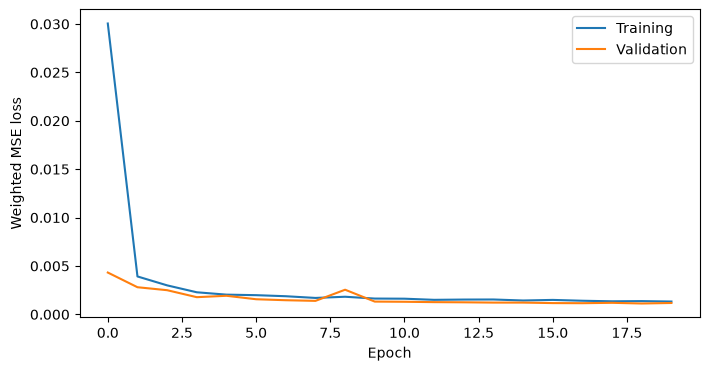

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Training")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Weighted MSE loss")
plt.legend()
plt.show()

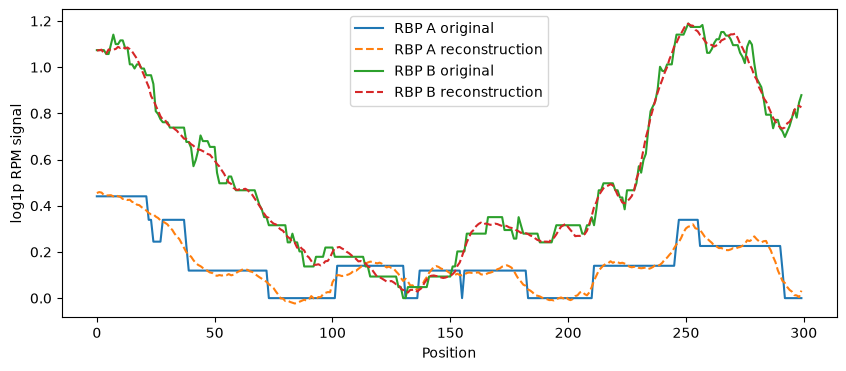

In [25]:
batch_signals, batch_weights = next(iter(train_loader))
batch_signals = batch_signals.to(device)

reconstruction = model(batch_signals)

i = 0

original = batch_signals[i].detach().cpu().numpy()
reconstructed = reconstruction[i].detach().cpu().numpy()

plt.figure(figsize=(10, 4))

plt.plot(original[0], label="RBP A original")
plt.plot(reconstructed[0], label="RBP A reconstruction", linestyle="--")

plt.plot(original[1], label="RBP B original")
plt.plot(reconstructed[1], label="RBP B reconstruction", linestyle="--")

plt.xlabel("Position")
plt.ylabel("log1p RPM signal")
plt.legend()
plt.show()

## Clustering/PCA

In [34]:
def build_validation_pca(model, val_loader, val_metadata, device):
    model.eval()

    latent_vectors = []
    validation_signals = []

    with torch.no_grad():
        for batch_signals, batch_weights in val_loader:
            batch_signals = batch_signals.to(device)

            latent = model.encode(batch_signals)

            latent_vectors.append(latent.cpu().numpy())
            validation_signals.append(batch_signals.cpu().numpy())

    latent_vectors = np.concatenate(latent_vectors, axis=0)
    validation_signals = np.concatenate(validation_signals, axis=0)

    if len(latent_vectors) != len(val_metadata):
        raise ValueError("Latent vectors and validation metadata are not aligned.")

    pca = PCA(n_components=2)
    latent_pca = pca.fit_transform(latent_vectors)

    pca_df = val_metadata.reset_index(drop=True).copy()
    pca_df["PC1"] = latent_pca[:, 0]
    pca_df["PC2"] = latent_pca[:, 1]
    pca_df["pair_label"] = pca_df["experiment_A"] + " vs " + pca_df["experiment_B"]
    pca_df["pair_key"] = [
        "__".join(sorted((a, b)))
        for a, b in zip(pca_df["experiment_A"], pca_df["experiment_B"])
    ]

    return pca, pca_df, latent_vectors, validation_signals


def plot_validation_pca(pca_df, pca, categories=None, comparison_ids=None, pairs=None,
                        color_by="category", point_size=10, alpha=0.5):
    plot_df = pca_df.copy()

    if categories is not None:
        plot_df = plot_df[plot_df["category"].isin(categories)]

    if comparison_ids is not None:
        plot_df = plot_df[plot_df["comparison_id"].isin(comparison_ids)]

    if pairs is not None:
        pair_keys = {"__".join(sorted(pair)) for pair in pairs}
        plot_df = plot_df[plot_df["pair_key"].isin(pair_keys)]

    if len(plot_df) == 0:
        print("No validation windows matched those filters.")
        return

    plt.figure(figsize=(7, 6))

    if color_by is None:
        plt.scatter(plot_df["PC1"], plot_df["PC2"], s=point_size, alpha=alpha)
    else:
        for label, group in plot_df.groupby(color_by, sort=False):
            plt.scatter(group["PC1"], group["PC2"], s=point_size, alpha=alpha, label=label)
        plt.legend()

    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
    plt.show()


# Build this once.
pca, pca_df, latent_vectors, validation_signals = build_validation_pca(
    model, val_loader, val_metadata, device
)

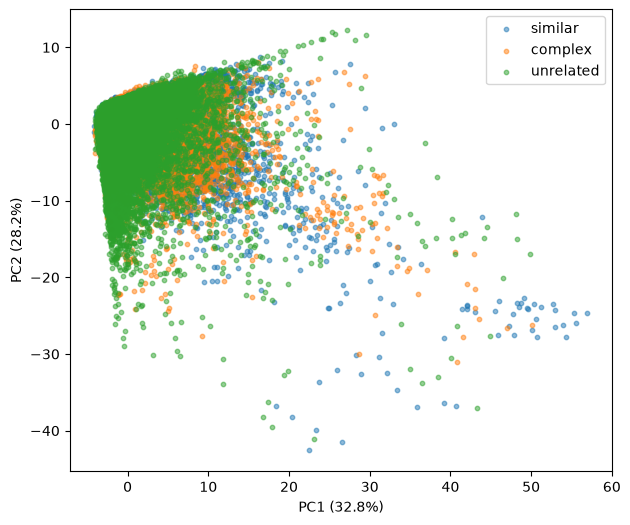

In [35]:
plot_validation_pca(pca_df, pca)

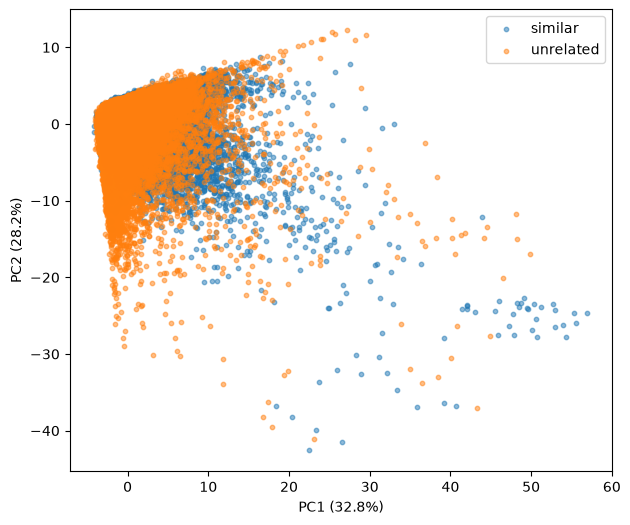

In [36]:
plot_validation_pca(
    pca_df, pca,
    categories=["similar", "unrelated"]
)

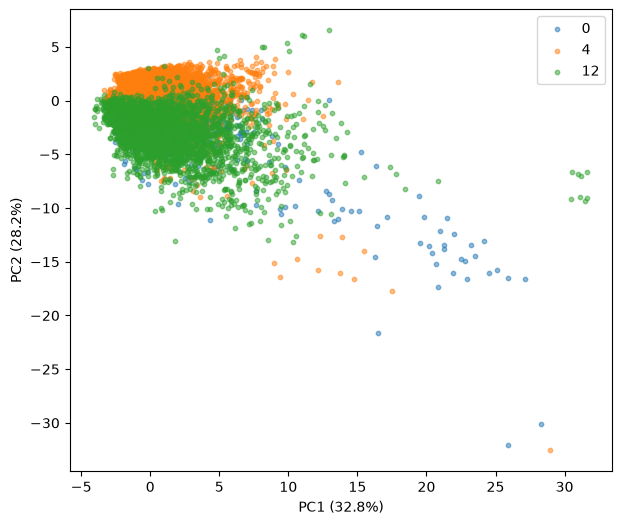

In [37]:
plot_validation_pca(
    pca_df, pca,
    comparison_ids=[0, 4, 12],
    color_by="comparison_id"
)

## Mean latent vectors

In [38]:
def build_comparison_latents(latent_vectors, val_metadata):
    metadata = val_metadata.reset_index(drop=True).copy()

    if len(latent_vectors) != len(metadata):
        raise ValueError("Latent vectors and validation metadata are not aligned.")

    metadata["latent_index"] = np.arange(len(metadata))

    comparison_rows = []
    comparison_latents = []

    for comparison_id, group in metadata.groupby("comparison_id", sort=False):
        indices = group["latent_index"].to_numpy()

        mean_latent = latent_vectors[indices].mean(axis=0)

        comparison_latents.append(mean_latent)
        comparison_rows.append({
            "comparison_id": comparison_id,
            "category": group["category"].iloc[0],
            "experiment_A": group["experiment_A"].iloc[0],
            "experiment_B": group["experiment_B"].iloc[0],
            "n_windows": len(group)
        })

    comparison_latents = np.stack(comparison_latents)
    comparison_metadata = pd.DataFrame(comparison_rows)

    comparison_metadata["pair_label"] = (
        comparison_metadata["experiment_A"] + " vs " +
        comparison_metadata["experiment_B"]
    )

    return comparison_latents, comparison_metadata

In [39]:
comparison_latents, comparison_metadata = build_comparison_latents(
    latent_vectors, val_metadata
)

print("Window latent vectors:", latent_vectors.shape)
print("Comparison latent vectors:", comparison_latents.shape)

Window latent vectors: (143119, 64)
Comparison latent vectors: (30, 64)


In [40]:
comparison_pca = PCA(n_components=2)
comparison_coords = comparison_pca.fit_transform(comparison_latents)

comparison_pca_df = comparison_metadata.copy()
comparison_pca_df["PC1"] = comparison_coords[:, 0]
comparison_pca_df["PC2"] = comparison_coords[:, 1]

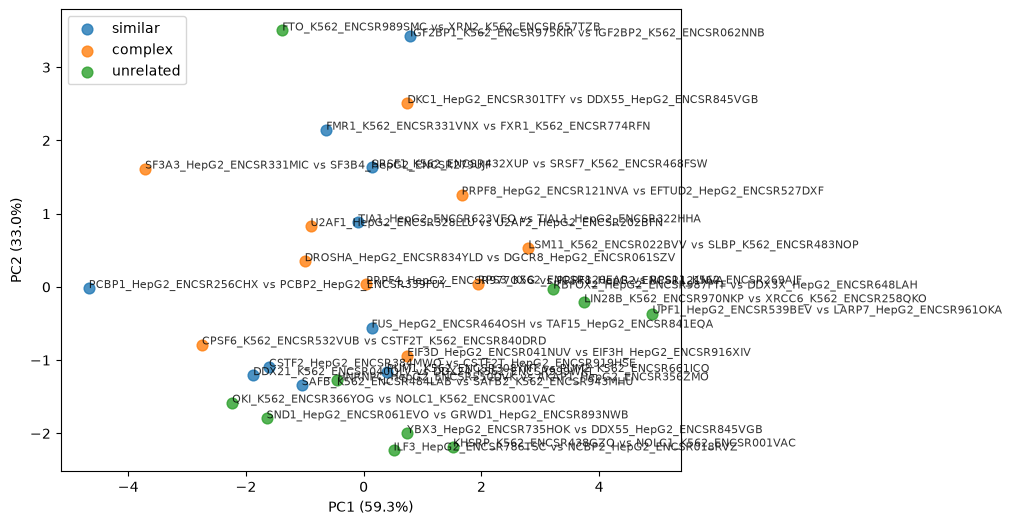

In [41]:
plt.figure(figsize=(8, 6))

for category, group in comparison_pca_df.groupby("category", sort=False):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        s=60,
        alpha=0.8,
        label=category
    )

for _, row in comparison_pca_df.iterrows():
    plt.annotate(
        row["pair_label"],
        (row["PC1"], row["PC2"]),
        fontsize=8,
        alpha=0.8
    )

plt.xlabel(f"PC1 ({comparison_pca.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({comparison_pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.legend()
plt.show()

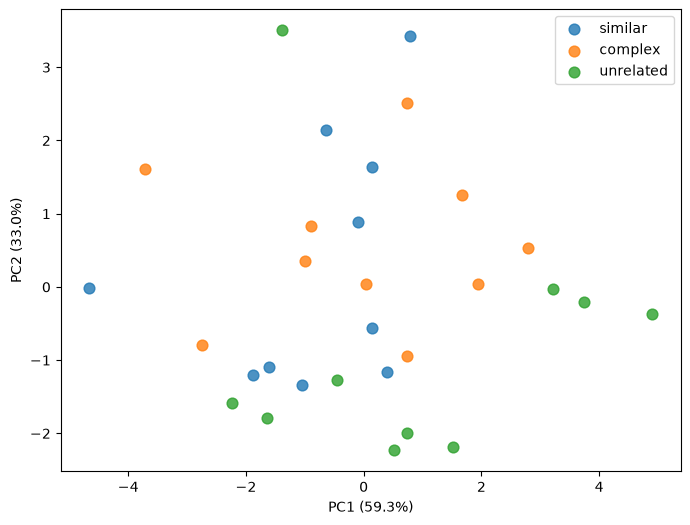

In [42]:
plt.figure(figsize=(8, 6))

for category, group in comparison_pca_df.groupby("category", sort=False):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        s=60,
        alpha=0.8,
        label=category
    )

plt.xlabel(f"PC1 ({comparison_pca.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({comparison_pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.legend()
plt.show()